In [41]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:85% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:20pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:20pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:20px;}
</style>
"""))

# 1. 데이터 생성
- 남여 키와 몸무게 데이터를 군집화

In [43]:
import random
import numpy as np
import matplotlib.pyplot as plt

In [44]:
random.randint(140,170)

169

In [45]:
data=[]
for i in range(50):
    # 여자 데이터(키와 몸무게) 추가
    data.append([random.randint(40,70),random.randint(140,170)])
    # 남자 데이터(키와 몸무게) 추가
    data.append([random.randint(60,95),random.randint(160,195)])

In [46]:
print('여자 몸무게(x축):',[female[0] for female in data[::2]])
print('여자 키(y축):',[female[1] for female in data[::2]])    

print('남자 몸무게(x축):',[male[0] for male in data[1::2]])
print('남자 키(y축):',[male[1] for male in data[1::2]])                     

여자 몸무게(x축): [65, 57, 49, 60, 51, 55, 70, 58, 68, 57, 47, 46, 54, 59, 70, 43, 44, 45, 50, 65, 49, 52, 64, 53, 56, 56, 64, 65, 47, 60, 59, 68, 44, 40, 57, 43, 62, 44, 64, 69, 64, 64, 44, 66, 66, 40, 56, 65, 52, 51]
여자 키(y축): [149, 169, 165, 154, 146, 149, 151, 163, 141, 159, 162, 151, 144, 161, 146, 164, 149, 141, 161, 150, 156, 155, 147, 164, 156, 156, 149, 143, 152, 163, 158, 148, 159, 165, 154, 144, 144, 151, 163, 147, 162, 159, 159, 154, 168, 170, 147, 158, 167, 140]
남자 몸무게(x축): [63, 72, 71, 87, 77, 75, 80, 67, 84, 75, 69, 81, 74, 80, 78, 63, 75, 61, 83, 87, 68, 62, 86, 87, 83, 92, 67, 63, 83, 73, 94, 73, 82, 65, 84, 87, 65, 66, 71, 91, 73, 79, 69, 85, 79, 78, 94, 80, 94, 84]
남자 키(y축): [187, 191, 169, 187, 185, 166, 167, 165, 192, 184, 182, 181, 174, 185, 170, 185, 162, 191, 179, 172, 176, 176, 193, 188, 174, 171, 169, 185, 193, 179, 168, 164, 168, 167, 190, 166, 177, 177, 178, 165, 162, 170, 194, 169, 176, 162, 179, 194, 187, 183]


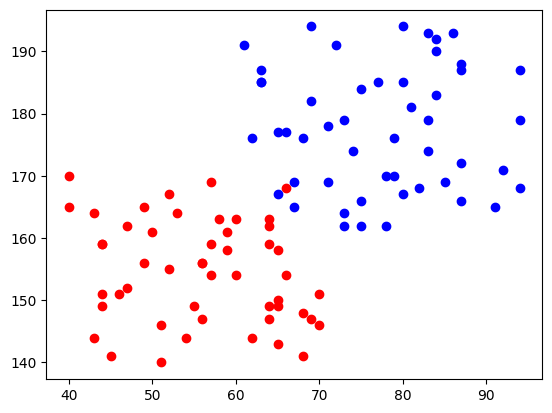

In [47]:
plt.plot([female[0] for female in data[::2]],
        [female[1] for female in data[::2]], 'o', color='r')
plt.plot([male[0] for male in data[1::2]],
        [male[1] for male in data[1::2]],'o',color='b')


# 2. 군집화 로직

In [48]:
# 초기 랜덤 지점 2개
random_points=[
    [random.randint(40,90),random.randint(140,195)],
    [random.randint(40,90),random.randint(140,195)]
]
random_points[0],random_points[1]

([45, 171], [64, 144])

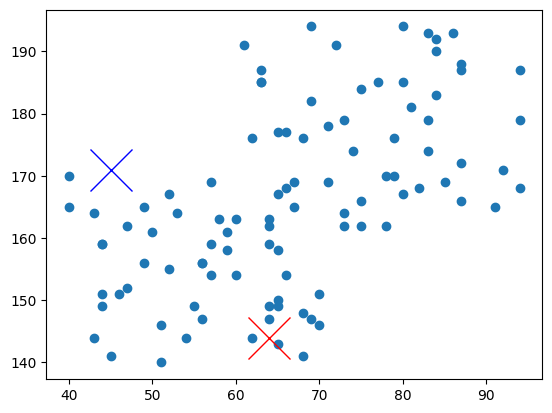

In [49]:
plt.plot([d[0] for d in data],
        [d[1] for d in data],'o')
plt.plot(random_points[0][0], random_points[0][1], 'x', markersize=30,color='b')# 기준점 0
plt.plot(random_points[1][0], random_points[1][1], 'x', markersize=30,color='r')# 기준점 1

In [50]:
# 두점거리를 return하는 함수 점은[50,150]
def dist(a,b):
    return np.sqrt((a[0]-b[0])**2 + (a[1]-b[1])**2)
print(dist([3,4],[0,0]))
print(dist([5,7],[-1,-1]))

5.0
10.0


In [51]:
 # random_points[0]에 가까운 그룹(group0)과 random_points[1]에 가까운 그룹(group1)을 분류
group0=[]
group1=[]
for d in data:
    if dist(random_points[0],d) < dist(random_points[1],d):
        group0.append(d)
    else:
        group1.append(d)
len(group0),len(group1)

(48, 52)

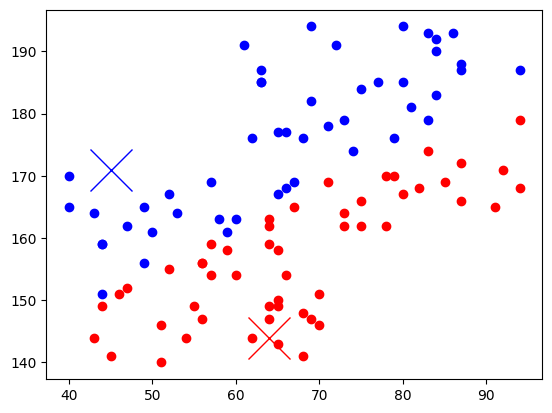

In [53]:
#group0과 group1, random_points[0]과 random_points[1]
plt.plot([d[0] for d in group0], [d[1] for d in group0], 'o', color='b')
plt.plot([d[0] for d in group1], [d[1] for d in group1], 'o', color='r')
plt.plot(random_points[0][0], random_points[0][1], 'x', markersize=30, color='b')
plt.plot(random_points[1][0], random_points[1][1], 'x', markersize=30, color='r')
plt.show()

In [54]:
# group0과 group1 중심점으로 기준점을 이용
group0_meanX = np.mean([d[0] for d in group0])
group0_meanY = np.mean([d[1] for d in group0])
random_points[0] = [group0_meanX,group0_meanY]

group1_meanX = np.mean([d[0] for d in group1])
group1_meanY = np.mean([d[1] for d in group1])
random_points[1] = [group1_meanX,group1_meanY]
random_points

[[66.04166666666667, 176.08333333333334],
 [67.03846153846153, 156.82692307692307]]

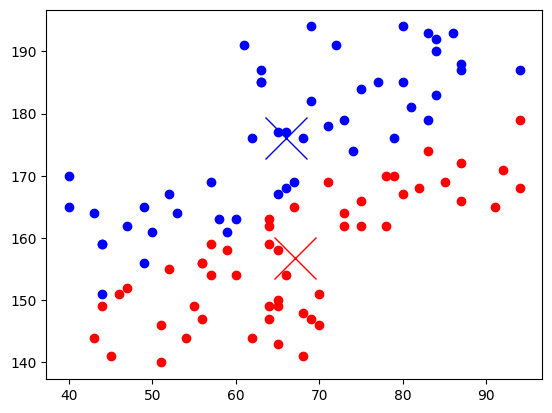

In [55]:
plt.plot([d[0] for d in group0], [d[1] for d in group0], 'o', color='b')
plt.plot([d[0] for d in group1], [d[1] for d in group1], 'o', color='r')
plt.plot(random_points[0][0], random_points[0][1], 'x', markersize=30, color='b')
plt.plot(random_points[1][0], random_points[1][1], 'x', markersize=30, color='r')
plt.show()